<a href="https://colab.research.google.com/github/fadlurrahmanh/Aplikasi-sederhana-simulasi-penyebaran-dbd-di-Jawa-Barat/blob/main/Simulasi_penyebaran_dbd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Memuat data DBD Jawa Barat...

Data DBD Jawa Barat 2016-2024:
   tahun  jumlah_kasus
0   2016         37279
1   2017          9637
2   2018         12492
3   2019         25282
4   2020         24471
5   2021         23454
6   2022         36608
7   2023         19328
8   2024         61423

Melakukan tuning parameter...
Parameter optimal: beta=0.2298, gamma=0.2380
R0 = 0.97

Menjalankan simulasi...


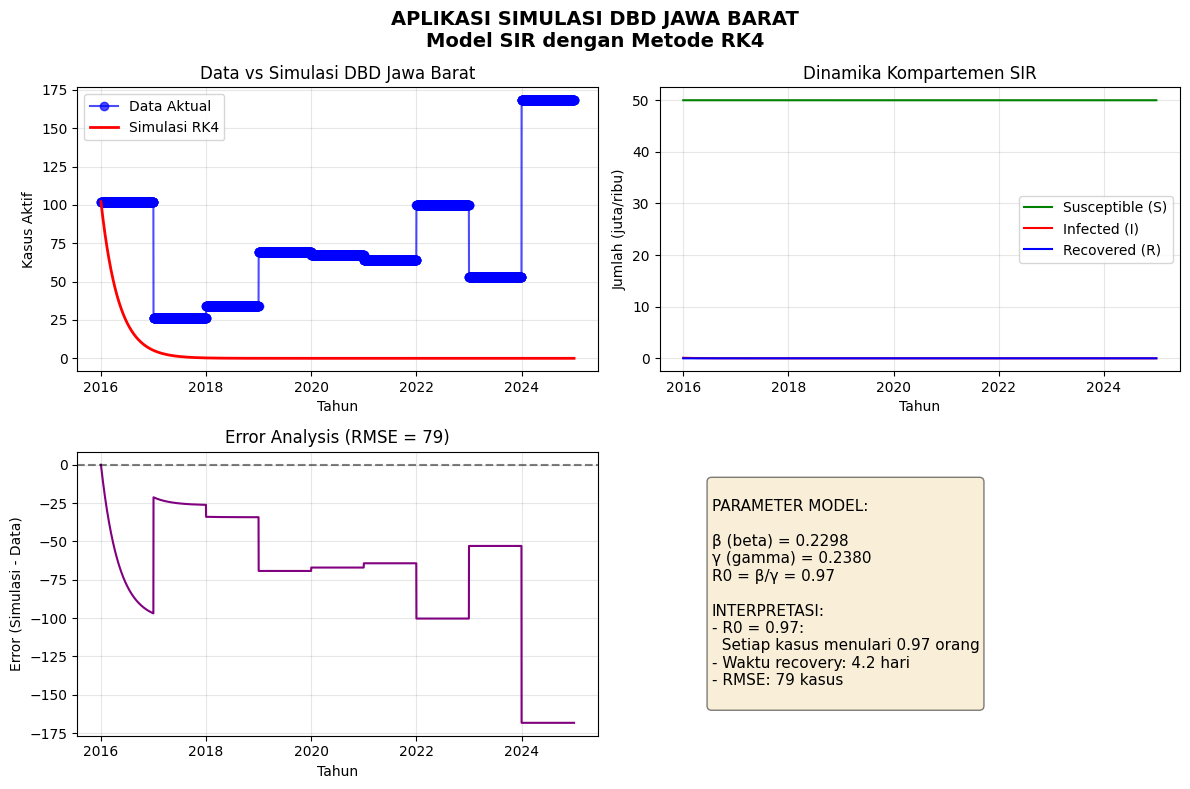


HASIL SIMULASI DBD JAWA BARAT
1. Parameter Epidemiologi:
   - Beta (laju transmisi): 0.2298
   - Gamma (laju recovery): 0.2380
   - R0 (angka reproduksi): 0.97
   - Lama sakit rata-rata: 4.2 hari

2. Statistik Simulasi:
   - Total kasus dalam 9 tahun: 2,973
   - Puncak kasus aktif: 102
   - Error (RMSE): 79 kasus

3. Rekomendasi:
   ✅ BAIK: R0 < 1, epidemi terkendali
   → Pertahankan surveilans dan pencegahan

APLIKASI SELESAI DIEKSEKUSI


In [ ]:
# ============================================
# APLIKASI SEDERHANA SIMULASI DBD JAWA BARAT
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==================== 1. LOAD DATA ====================
print("Memuat data DBD Jawa Barat...")
df = pd.read_csv('dinkes-od_18509_jml_kasus_penyakit_demam_berdarah_dengue_dbd__kabu_v3_data.csv')

# Agregasi per tahun
data_tahunan = df.groupby('tahun')['jumlah_kasus'].sum().reset_index()
print(f"\nData DBD Jawa Barat {data_tahunan['tahun'].min()}-{data_tahunan['tahun'].max()}:")
print(data_tahunan)

# ==================== 2. MODEL SIR ====================
def model_sir(t, y, beta, gamma, N):
    """Model SIR untuk DBD"""
    S, I, R = y
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    return [dS, dI, dR]

# ==================== 3. RK4 MANUAL ====================
def rk4_solver(f, t_span, y0, h, params):
    """Implementasi manual RK4"""
    t_start, t_end = t_span
    steps = int((t_end - t_start) / h) + 1
    t = np.linspace(t_start, t_end, steps)
    y = np.zeros((steps, len(y0)))
    y[0] = y0

    for i in range(steps-1):
        t_n = t[i]
        y_n = y[i]

        k1 = np.array(f(t_n, y_n, *params))
        k2 = np.array(f(t_n + h/2, y_n + h*k1/2, *params))
        k3 = np.array(f(t_n + h/2, y_n + h*k2/2, *params))
        k4 = np.array(f(t_n + h, y_n + h*k3, *params))

        y[i+1] = y_n + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return t, y

# ==================== 4. PARAMETER TUNING ====================
print("\nMelakukan tuning parameter...")

# Konversi data tahunan ke harian (untuk simulasi)
days = 365 * len(data_tahunan)
t_data = np.arange(days)

# Distribusi kasus tahunan ke harian
I_data = []
for _, row in data_tahunan.iterrows():
    kasus_tahunan = row['jumlah_kasus']
    kasus_harian = kasus_tahunan / 365
    I_data.extend([kasus_harian] * 365)
I_data = np.array(I_data)

# Parameter populasi
N = 50_000_000  # Populasi Jawa Barat
S0 = N - I_data[0] - 0
I0 = I_data[0]
R0 = 0

# Fungsi error
def error_function(params):
    beta, gamma = params
    t, y = rk4_solver(lambda t, y, b, g, N: model_sir(t, y, b, g, N),
                      (0, days-1), [S0, I0, R0], 1, (beta, gamma, N))
    rmse = np.sqrt(np.mean((y[:, 1] - I_data)**2))
    return rmse

# Optimisasi sederhana
result = minimize(error_function, [0.3, 0.1], bounds=[(0.1, 0.8), (0.05, 0.3)])
beta_opt, gamma_opt = result.x
print(f"Parameter optimal: beta={beta_opt:.4f}, gamma={gamma_opt:.4f}")
print(f"R0 = {beta_opt/gamma_opt:.2f}")

# ==================== 5. SIMULASI ====================
print("\nMenjalankan simulasi...")
t, y = rk4_solver(lambda t, y, b, g, N: model_sir(t, y, b, g, N),
                  (0, days-1), [S0, I0, R0], 1, (beta_opt, gamma_opt, N))

# ==================== 6. VISUALISASI ====================
plt.figure(figsize=(12, 8))

# Plot 1: Data vs Simulasi
plt.subplot(2, 2, 1)
plt.plot(t_data/365 + 2016, I_data, 'bo-', alpha=0.7, label='Data Aktual')
plt.plot(t/365 + 2016, y[:, 1], 'r-', linewidth=2, label='Simulasi RK4')
plt.xlabel('Tahun')
plt.ylabel('Kasus Aktif')
plt.title('Data vs Simulasi DBD Jawa Barat')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Kompartemen SIR
plt.subplot(2, 2, 2)
plt.plot(t/365 + 2016, y[:, 0]/1e6, 'g-', label='Susceptible (S)')
plt.plot(t/365 + 2016, y[:, 1]/1e3, 'r-', label='Infected (I)')
plt.plot(t/365 + 2016, y[:, 2]/1e6, 'b-', label='Recovered (R)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah (juta/ribu)')
plt.title('Dinamika Kompartemen SIR')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Error
plt.subplot(2, 2, 3)
error = y[:, 1] - I_data
plt.plot(t/365 + 2016, error, 'purple')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Tahun')
plt.ylabel('Error (Simulasi - Data)')
plt.title(f'Error Analysis (RMSE = {result.fun:.0f})')
plt.grid(True, alpha=0.3)

# Plot 4: Parameter Info
plt.subplot(2, 2, 4)
plt.axis('off')
info_text = f"""
PARAMETER MODEL:

β (beta) = {beta_opt:.4f}
γ (gamma) = {gamma_opt:.4f}
R0 = β/γ = {beta_opt/gamma_opt:.2f}

INTERPRETASI:
- R0 = {beta_opt/gamma_opt:.2f}:
  Setiap kasus menulari {beta_opt/gamma_opt:.2f} orang
- Waktu recovery: {1/gamma_opt:.1f} hari
- RMSE: {result.fun:.0f} kasus
"""
plt.text(0.1, 0.5, info_text, fontsize=11,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('APLIKASI SIMULASI DBD JAWA BARAT\nModel SIR dengan Metode RK4',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('simulasi_dbd_simple.png', dpi=120, bbox_inches='tight')
plt.show()

# ==================== 7. OUTPUT HASIL ====================
print("\n" + "="*50)
print("HASIL SIMULASI DBD JAWA BARAT")
print("="*50)
print(f"1. Parameter Epidemiologi:")
print(f"   - Beta (laju transmisi): {beta_opt:.4f}")
print(f"   - Gamma (laju recovery): {gamma_opt:.4f}")
print(f"   - R0 (angka reproduksi): {beta_opt/gamma_opt:.2f}")
print(f"   - Lama sakit rata-rata: {1/gamma_opt:.1f} hari")

print(f"\n2. Statistik Simulasi:")
print(f"   - Total kasus dalam {len(data_tahunan)} tahun: {y[-1, 2]:,.0f}")
print(f"   - Puncak kasus aktif: {y[:, 1].max():,.0f}")
print(f"   - Error (RMSE): {result.fun:,.0f} kasus")

print(f"\n3. Rekomendasi:")
if beta_opt/gamma_opt > 1:
    print(f"   ⚠️  WASPADA: R0 > 1, epidemi masih aktif")
    print(f"   → Perlu intensifkan 3M Plus dan fogging")
else:
    print(f"   ✅ BAIK: R0 < 1, epidemi terkendali")
    print(f"   → Pertahankan surveilans dan pencegahan")

# Simpan parameter ke file
with open('parameter.txt', 'w') as f:
    f.write(f"Parameter Model SIR DBD Jawa Barat\n")
    f.write(f"===================================\n")
    f.write(f"Beta (β): {beta_opt:.6f}\n")
    f.write(f"Gamma (γ): {gamma_opt:.6f}\n")
    f.write(f"R0: {beta_opt/gamma_opt:.2f}\n")
    f.write(f"Populasi (N): {N:,}\n")
    f.write(f"RMSE: {result.fun:.2f}\n")